# 🛍️ Retail Store Sales Analysis

## 1. Project Overview

This project analyzes store characteristics, revenue performance, and revenue efficiency across **118 retail stores**. The workflow combines data cleaning, business-oriented exploratory analysis, feature engineering, and leakage-safe regression modeling.

The modeling section uses numerical and categorical store attributes, evaluates multiple regressors with **5-fold cross-validation**, and keeps `RevToArea` out of the prediction features because it is derived from the target.

### 🌐 Interactive Dashboard
👉 [Open Live Retail Store Sales Dashboard](https://mr-amirasgari.github.io/kaggle-data-science-projects/retail-store-sales-analysis/)

### 📂 Source Code
👉 [View Project on GitHub](https://github.com/mr-amirasgari/kaggle-data-science-projects/tree/main/retail-store-sales-analysis)

## 2. Environment & Data Loading

The notebook prefers the attached Kaggle dataset and falls back to the repository copy for local execution.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 50)

candidates = [
    Path("/kaggle/input/datasets/mramirasgari/stores/Stores.csv"),
    Path("data/Stores.csv"),
    Path("Stores.csv"),
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Stores.csv was not found. Attach the Kaggle dataset or place the file in data/Stores.csv.")

raw = pd.read_csv(data_path)
print("Data path:", data_path)
print("Dataset shape:", raw.shape)
raw.head()

Data path: data/Stores.csv
Dataset shape: (118, 7)


,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
0,1,2100.0,Owned,Hyper,New,6.0,"45,072,000"
1,2,1290.0,Cooperate,Extra,New,5.0,"7,416,000"
2,3,500.0,Rental,Express,New,NaN,"8,592,000"
3,4,2000.0,Owned,Hyper,New,9.0,"48,415,500"
4,5,220.0,Rental,Express,Old,2.0,"3,345,500"


## 3. Dataset Overview & Data Quality

The source contains 7 columns. `Revenue` is initially text because of comma separators, and `Checkout Number` contains missing values.

In [2]:
print("Column types:")
print(raw.dtypes)
print("\nMissing values:")
print(raw.isna().sum())
print("\nDuplicated rows:", raw.duplicated().sum())
raw.describe(include="all")

Column types:
Store Number         int64
AreaStore          float64
Property            object
Type                object
Old/New             object
Checkout Number    float64
Revenue             object
dtype: object

Missing values:
Store Number        0
AreaStore           0
Property            0
Type                0
Old/New             0
Checkout Number    12
Revenue             0
dtype: int64

Duplicated rows: 0


,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
count,118.000000,118.000000,118,118,118,106.000000,118
unique,NaN,NaN,7,3,4,NaN,117
top,NaN,NaN,Owned,Express,New,NaN,"11,031,500"
freq,NaN,NaN,39,55,93,NaN,2
mean,59.500000,1373.608136,NaN,NaN,NaN,4.792453,NaN
std,34.207699,1092.453470,NaN,NaN,NaN,2.820729,NaN
min,1.000000,82.000000,NaN,NaN,NaN,1.000000,NaN
25%,30.250000,530.500000,NaN,NaN,NaN,3.000000,NaN
50%,59.500000,1000.000000,NaN,NaN,NaN,4.000000,NaN
75%,88.750000,1887.500000,NaN,NaN,NaN,6.000000,NaN


### 3.1 Categorical Label Audit

Some labels contain trailing spaces. These formatting inconsistencies would split identical business categories into separate groups if left untreated.

In [3]:
for column in ["Property", "Type", "Old/New"]:
    print(f"{column}: {raw[column].value_counts(dropna=False).to_dict()}")

Property: {'Owned': 39, 'Cooperate': 27, 'Rental': 26, 'Rental/Cooperate': 15, 'Rental ': 7, 'Owned ': 2, 'Cooperate ': 2}
Type: {'Express': 55, 'Extra': 36, 'Hyper': 27}
Old/New: {'New': 93, 'Old': 11, 'New ': 9, 'Old ': 5}


## 4. Data Cleaning & Feature Engineering

Cleaning is intentionally simple and reproducible:

- strip leading/trailing spaces from categorical labels;
- remove comma separators from `Revenue` and convert it to numeric;
- keep missing `Checkout Number` values in the analysis table;
- create `RevToArea = Revenue / AreaStore` for business analysis only.

Missing checkout values are **not** filled globally before modeling. Imputation happens inside the scikit-learn pipeline so each cross-validation fold learns its median from training data only.

In [4]:
df = raw.copy()
for column in ["Property", "Type", "Old/New"]:
    df[column] = df[column].astype(str).str.strip()

df["Revenue"] = df["Revenue"].str.replace(",", "", regex=False).astype(float)
df["RevToArea"] = df["Revenue"] / df["AreaStore"]

print("Cleaned categories:")
for column in ["Property", "Type", "Old/New"]:
    print(column, sorted(df[column].unique()))

print("\nMissing Checkout Number:", int(df["Checkout Number"].isna().sum()))
df.head()

Cleaned categories:
Property ['Cooperate', 'Owned', 'Rental', 'Rental/Cooperate']
Type ['Express', 'Extra', 'Hyper']
Old/New ['New', 'Old']

Missing Checkout Number: 12


,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,RevToArea
0,1,2100.0,Owned,Hyper,New,6.0,45072000.0,21462.857143
1,2,1290.0,Cooperate,Extra,New,5.0,7416000.0,5748.837209
2,3,500.0,Rental,Express,New,NaN,8592000.0,17184.000000
3,4,2000.0,Owned,Hyper,New,9.0,48415500.0,24207.750000
4,5,220.0,Rental,Express,Old,2.0,3345500.0,15206.818182


## 5. Exploratory Data Analysis

### 5.1 Revenue Distribution

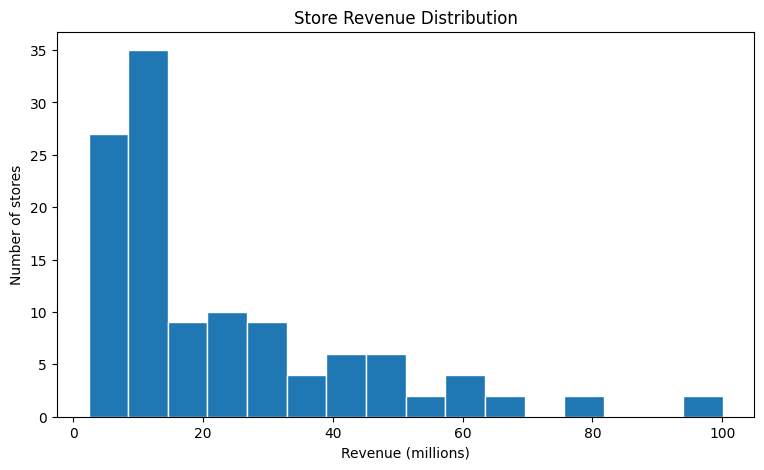

Total revenue: 2,713,770,000
Mean revenue: 22,998,051
Median revenue: 13,584,750


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Revenue"] / 1_000_000, bins=16, edgecolor="white")
ax.set_title("Store Revenue Distribution")
ax.set_xlabel("Revenue (millions)")
ax.set_ylabel("Number of stores")
plt.show()

print("Total revenue:", f"{df['Revenue'].sum():,.0f}")
print("Mean revenue:", f"{df['Revenue'].mean():,.0f}")
print("Median revenue:", f"{df['Revenue'].median():,.0f}")

### 5.2 Revenue vs. Store Area

Store area and revenue have a clear positive relationship, but stores with similar footprints can still produce very different revenue levels.

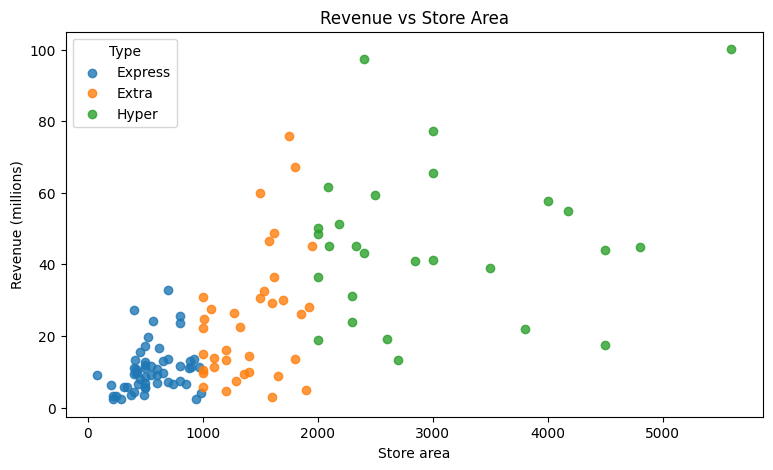

                 Revenue  AreaStore  Checkout Number
Revenue            1.000      0.683            0.808
AreaStore          0.683      1.000            0.873
Checkout Number    0.808      0.873            1.000


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for store_type, group in df.groupby("Type"):
    ax.scatter(group["AreaStore"], group["Revenue"] / 1_000_000, label=store_type, alpha=0.8)
ax.set_title("Revenue vs Store Area")
ax.set_xlabel("Store area")
ax.set_ylabel("Revenue (millions)")
ax.legend(title="Type")
plt.show()

print(df[["Revenue", "AreaStore", "Checkout Number"]].corr(numeric_only=True).round(3))

### 5.3 Revenue by Store Type

In [7]:
type_summary = (
    df.groupby("Type")
      .agg(
          Stores=("Store Number", "count"),
          TotalRevenue=("Revenue", "sum"),
          AverageRevenue=("Revenue", "mean"),
          MedianRevenuePerArea=("RevToArea", "median"),
          AverageArea=("AreaStore", "mean"),
      )
      .sort_values("TotalRevenue", ascending=False)
)
type_summary

,Stores,TotalRevenue,AverageRevenue,MedianRevenuePerArea,AverageArea
Type,,,,,
Hyper,27,1.248994e+09,4.625904e+07,14406.535488,2986.370370
Extra,36,8.817890e+08,2.449414e+07,14819.363636,1410.944444
Express,55,5.829870e+08,1.059976e+07,16661.764706,557.450182


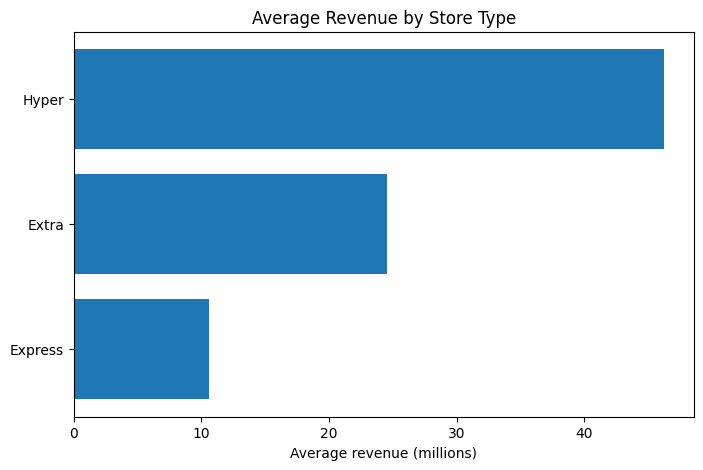

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = (type_summary["AverageRevenue"] / 1_000_000).sort_values()
ax.barh(plot_data.index, plot_data.values)
ax.set_title("Average Revenue by Store Type")
ax.set_xlabel("Average revenue (millions)")
plt.show()

### 5.4 Revenue by Property and Store Age

In [9]:
property_summary = (
    df.groupby("Property")
      .agg(Stores=("Store Number", "count"), TotalRevenue=("Revenue", "sum"), AverageRevenue=("Revenue", "mean"), MedianRevenuePerArea=("RevToArea", "median"))
      .sort_values("TotalRevenue", ascending=False)
)
age_summary = (
    df.groupby("Old/New")
      .agg(Stores=("Store Number", "count"), TotalRevenue=("Revenue", "sum"), AverageRevenue=("Revenue", "mean"), MedianRevenuePerArea=("RevToArea", "median"))
      .sort_values("TotalRevenue", ascending=False)
)
print("Property summary")
display(property_summary)
print("Store age summary")
display(age_summary)

Property summary


,Stores,TotalRevenue,AverageRevenue,MedianRevenuePerArea
Property,,,,
Owned,41,1.603556e+09,3.911113e+07,20808.962264
Rental,33,4.267175e+08,1.293083e+07,15230.833333
Cooperate,29,3.827600e+08,1.319862e+07,13617.000000
Rental/Cooperate,15,3.007360e+08,2.004907e+07,13533.913043


Store age summary


,Stores,TotalRevenue,AverageRevenue,MedianRevenuePerArea
Old/New,,,,
New,102,2.538870e+09,2.489088e+07,16803.461778
Old,16,1.749000e+08,1.093125e+07,14947.138771


## 6. Store Performance Insights

`RevToArea` is useful for comparing stores of different sizes. It is an analytical KPI, not a model input.

In [10]:
print("Top 10 stores by revenue")
display(df.nlargest(10, "Revenue")[["Store Number", "Type", "Property", "AreaStore", "Checkout Number", "Revenue", "RevToArea"]])

print("Top 10 stores by revenue per area")
display(df.nlargest(10, "RevToArea")[["Store Number", "Type", "Property", "AreaStore", "Revenue", "RevToArea"]])

Top 10 stores by revenue


,Store Number,Type,Property,AreaStore,Checkout Number,Revenue,RevToArea
43,44,Hyper,Owned,5600.0,14.0,100083000.0,17871.964286
85,86,Hyper,Owned,2400.0,10.0,97408000.0,40586.666667
32,33,Hyper,Owned,3000.0,11.0,77139500.0,25713.166667
34,35,Extra,Owned,1750.0,9.0,75874500.0,43356.857143
45,46,Extra,Rental/Cooperate,1800.0,NaN,67093000.0,37273.888889
49,50,Hyper,Owned,3000.0,13.0,65403500.0,21801.166667
90,91,Hyper,Owned,2085.0,7.0,61497000.0,29494.964029
93,94,Extra,Owned,1500.0,7.0,59794500.0,39863.000000
74,75,Hyper,Owned,2500.0,8.0,59349000.0,23739.600000
6,7,Hyper,Owned,4000.0,13.0,57620000.0,14405.000000


Top 10 stores by revenue per area


,Store Number,Type,Property,AreaStore,Revenue,RevToArea
52,53,Express,Owned,82.0,9087000.0,110817.073171
17,18,Express,Rental,397.0,27337000.0,68858.942065
41,42,Express,Owned,700.0,32913000.0,47018.571429
34,35,Extra,Owned,1750.0,75874500.0,43356.857143
79,80,Express,Rental,562.0,24214000.0,43085.409253
85,86,Hyper,Owned,2400.0,97408000.0,40586.666667
93,94,Extra,Owned,1500.0,59794500.0,39863.000000
110,111,Express,Owned,524.0,19610000.0,37423.664122
45,46,Extra,Rental/Cooperate,1800.0,67093000.0,37273.888889
88,89,Express,Owned,500.0,17252000.0,34504.000000


## 7. Leakage-Safe Model Preparation

The target is `Revenue`. The model uses:

- `AreaStore`
- `Checkout Number`
- `Property`
- `Type`
- `Old/New`

`Store Number` is an identifier and is excluded. `RevToArea` is excluded because it contains the target by construction.

Numerical imputation/scaling and categorical one-hot encoding are performed inside a `ColumnTransformer` within each pipeline.

In [11]:
features = ["AreaStore", "Property", "Type", "Old/New", "Checkout Number"]
target = "Revenue"

X = df[features]
y = df[target]

numeric_features = ["AreaStore", "Checkout Number"]
categorical_features = ["Property", "Type", "Old/New"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Features:", features)
print("Target:", target)

Features: ['AreaStore', 'Property', 'Type', 'Old/New', 'Checkout Number']
Target: Revenue


## 8. Model Comparison with 5-Fold Cross-Validation

Three models are compared on the same folds using MAE, RMSE, and R². Cross-validation is emphasized because the dataset contains only 118 stores.

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Extra Trees": ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, regressor in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", regressor),
    ])
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
        },
    )
    rows.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "R2 Std": scores["test_R2"].std(),
    })

model_comparison = pd.DataFrame(rows).sort_values("CV R2", ascending=False).reset_index(drop=True)
model_comparison.style.format({"CV MAE": "{:,.0f}", "CV RMSE": "{:,.0f}", "CV R2": "{:.3f}", "R2 Std": "{:.3f}"})

,Model,CV MAE,CV RMSE,CV R2,R2 Std
0,Ridge Regression,"8,694,963","12,057,494",0.572,0.140
1,Extra Trees,"8,789,838","12,579,545",0.546,0.136
2,Linear Regression,"8,579,975","12,245,991",0.545,0.190


## 9. Selected Model: Ridge Regression

Ridge Regression is selected because it achieved the strongest mean cross-validated R² in this experiment while retaining a simple, regularized linear structure.

A fixed 80/20 split is used below only to generate a concrete holdout error summary and Actual-vs-Predicted plot. Model selection itself is based on cross-validation.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

selected_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0)),
])
selected_model.fit(X_train, y_train)
y_pred = selected_model.predict(X_test)

holdout_metrics = pd.Series({
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
    "R2": r2_score(y_test, y_pred),
})

holdout_metrics

MAE     8.977420e+06
RMSE    1.413737e+07
R2      3.943100e-01
dtype: float64

### 9.1 Actual vs. Predicted Revenue

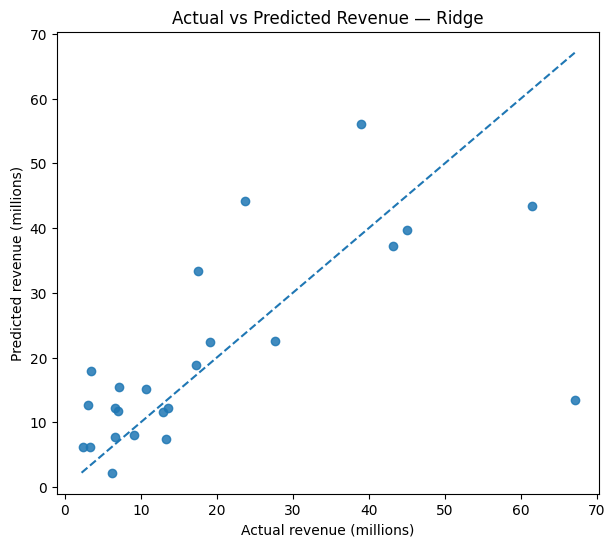

,Actual Revenue,Predicted Revenue
56,43200500.0,3.718083e+07
89,6545000.0,7.739344e+06
4,3345500.0,6.238630e+06
45,67093000.0,1.343299e+07
26,3478000.0,1.790269e+07
116,6173500.0,2.207942e+06
69,17560500.0,3.340126e+07
10,7104000.0,1.545009e+07
90,61497000.0,4.342398e+07
73,13616500.0,1.216342e+07


In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test / 1_000_000, y_pred / 1_000_000, alpha=0.85)
low = min(y_test.min(), y_pred.min()) / 1_000_000
high = max(y_test.max(), y_pred.max()) / 1_000_000
ax.plot([low, high], [low, high], linestyle="--")
ax.set_title("Actual vs Predicted Revenue — Ridge")
ax.set_xlabel("Actual revenue (millions)")
ax.set_ylabel("Predicted revenue (millions)")
plt.show()

comparison = pd.DataFrame({"Actual Revenue": y_test, "Predicted Revenue": y_pred})
comparison.head(10)

### 9.2 Residual Analysis

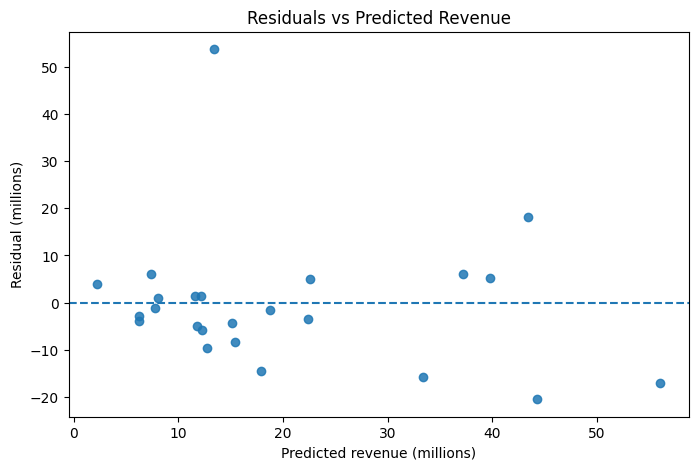

In [15]:
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred / 1_000_000, residuals / 1_000_000, alpha=0.85)
ax.axhline(0, linestyle="--")
ax.set_title("Residuals vs Predicted Revenue")
ax.set_xlabel("Predicted revenue (millions)")
ax.set_ylabel("Residual (millions)")
plt.show()

## 10. Ridge Coefficients

The model is refit on all 118 stores for coefficient inspection. Numerical coefficients correspond to standardized variables; one-hot coefficients are relative contributions within the regularized linear model and should not be interpreted causally.

In [16]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0)),
])
final_model.fit(X, y)

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": final_model.named_steps["model"].coef_,
})
coefficients["AbsoluteCoefficient"] = coefficients["Coefficient"].abs()
coefficients.sort_values("AbsoluteCoefficient", ascending=False).drop(columns="AbsoluteCoefficient")

,Feature,Coefficient
1,num__Checkout Number,9.282985e+06
3,cat__Property_Owned,7.066725e+06
0,num__AreaStore,3.579012e+06
5,cat__Property_Rental/Cooperate,-3.338927e+06
8,cat__Type_Hyper,3.066169e+06
2,cat__Property_Cooperate,-2.009852e+06
7,cat__Type_Extra,-1.723153e+06
4,cat__Property_Rental,-1.717946e+06
6,cat__Type_Express,-1.343017e+06
10,cat__Old/New_Old,-7.927080e+05


## 11. Key Findings

- The dataset contains **118 stores** and **12 missing checkout counts** before model-side imputation.
- Category cleaning reduces `Property` to four consistent labels and `Old/New` to two labels.
- Total recorded revenue is **2,713,770,000**, with a median store revenue of **13,584,750**.
- Revenue is positively associated with store area and especially checkout count in this sample.
- **Hyper** stores have the highest total and average revenue, while **Express** stores have the highest median revenue per unit of area among store types.
- Store **44** has the highest absolute revenue (**100,083,000**).
- Store **53** has the highest `RevToArea` (**110,817.07**).
- In 5-fold cross-validation, **Ridge Regression** provides the strongest mean R² among the three evaluated models (about **0.57**).
- The selected Ridge holdout result is approximately **R² = 0.39**, **MAE = 8.98M**, and **RMSE = 14.14M**.

## 12. Conclusion

This project moves beyond a two-feature baseline by incorporating categorical store characteristics and evaluating models with leakage-safe pipelines and cross-validation.

The results show that physical capacity and store format explain a meaningful share of revenue variation, but substantial unexplained variation remains. With only 118 stores, the model should be treated as a portfolio regression experiment rather than a production forecasting system.

Future work would benefit most from additional operational variables such as location, customer traffic, product mix, local demographics, promotion intensity, and time-series sales history.

---

### 🌐 Interactive Dashboard
👉 [Open the Live Dashboard](https://mr-amirasgari.github.io/kaggle-data-science-projects/retail-store-sales-analysis/)

### 📂 Source Code
👉 [View the Project on GitHub](https://github.com/mr-amirasgari/kaggle-data-science-projects/tree/main/retail-store-sales-analysis)